<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_19_Automating_Time_Series_Forecasting_with_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 19: Automating Time Series Forecasting with Prophet

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

## Part 4 begins

Through chapters 1-18 we built every forecasting model **by hand**. We wrote functions to search over $(p, d, q, P, D, Q)$ to minimize AIC, validated residuals with Q-Q plots and Ljung-Box tests, designed rolling forecast procedures, defined data windows for neural networks, built CNNs, LSTMs, and autoregressive-LSTMs from scratch in Keras. That manual control gave us deep insight into *how* each method works, but it also makes each new dataset a multi-hour engineering exercise.

Part 4 (chapters 19-20) introduces the other side of the workflow: **automated forecasting libraries**, where most of that engineering is wrapped in high-level APIs. The headline library is **Prophet**, built by Meta (formerly Facebook) for internal business forecasting at scale and open-sourced in 2017. Prophet's design choices reflect the typical business-forecasting use case:

- **Most series have multiple seasonal periods** (e.g., daily-and-weekly retail traffic, hourly-and-yearly utility demand). Prophet uses Fourier series to model arbitrarily many periodic components simultaneously.
- **Trends change over time** (product launches, market shifts). Prophet automatically detects trend changepoints.
- **Holidays matter for retail, travel, finance**. Prophet can attach country-specific holiday calendars.
- **Outliers and missing data are common**. Prophet's MAP/Bayesian fitting is robust to both.
- **Speed matters when you forecast thousands of series**. Prophet fits in seconds, not minutes.

**The core model.** Prophet decomposes each time series into a generalized additive model:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

where $g(t)$ is a piecewise-linear (or logistic) trend, $s(t)$ is a sum of Fourier-series seasonal components, $h(t)$ is a holiday-effect indicator function, and $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ is i.i.d. Gaussian noise. Notice what is **not** in this equation: any lagged $y$. Unlike ARIMA, Prophet does not model the *autocorrelation* structure of the series -- it is a **curve-fitting** approach rather than a state-evolution approach. This is the design tradeoff: less predictive power on highly autocorrelated series, but much more flexibility on series with strong seasonality, holidays, and changing trends.

**What this chapter does.** In four parts:

1. **Overview** (Section 19.1): a brief survey of automated-forecasting libraries -- pmdarima, Prophet, NeuralProphet, PyTorch Forecasting -- and why we focus on Prophet.
2. **Prophet's internals** (Section 19.2): the additive model, the Fourier seasonal expansion, holiday effects, and where Prophet excels vs. struggles.
3. **Basic Prophet workflow** (Section 19.3): the canonical `df.columns = ['ds', 'y']` -> `Prophet().fit(train)` -> `make_future_dataframe` -> `predict` pipeline on the **daily minimum temperature in Melbourne** dataset. Compare against a naive-last-year baseline.
4. **Advanced Prophet** (Section 19.4): visualization (`plot`, `plot_components`, `add_changepoints_to_plot`), cross-validation, performance metrics, and hyperparameter tuning. Build a robust process that combines all three.

**A note on the package name.** The book uses `from fbprophet import Prophet`. The package was renamed in 2021: the modern import is `from prophet import Prophet`. The API is identical; only the module name changed. Throughout this notebook we use `prophet`.

**Connection to earlier benchmarks.** In Part 1 we established that ARIMA($3$, $2$, $3$) beat the naive seasonal benchmark of MAPE $= 11.56\%$ on J&J EPS by a factor of $5\times$. In Part 3 we showed that deep learning (LSTM, AR-LSTM) beat baselines by $\sim 4\times$ on metro traffic. In this chapter we use a *different* dataset (Melbourne temperature) with no carry-over benchmark; we will establish a fresh naive-last-year baseline and beat it with Prophet. The book's punchline: Prophet halves the MAE compared to the baseline ($2.87 \to 1.94$).


## 19.1 Overview of automated forecasting libraries

Four libraries dominate the open-source automated-forecasting landscape as of the book's writing:

**pmdarima** (`pmdarima.arima`) wraps the popular R package `forecast::auto.arima` for Python. It automates everything we did manually in chapters 4-9: ADF testing, seasonal differencing, $(p, d, q, P, D, Q)$ grid search, residual diagnostics, AIC minimization. Best for users who already know ARIMA and want a one-line interface. Limitation: it inherits ARIMA's restrictions (one seasonal period, linear dynamics, slow on large datasets).

**Prophet** (`prophet`) implements Meta's generalized additive model. Best for series with strong seasonal structure (multiple periods, holidays, changing trends), large enough datasets to fit the trend reliably ($\ge 2$-$3$ full seasons of history), and use cases where forecast intervals matter as much as point forecasts. Limitation: weaker on highly autocorrelated short series where ARIMA's lag structure is the right inductive bias.

**NeuralProphet** (`neuralprophet`) is a PyTorch-based successor to Prophet that adds optional autoregressive ($AR$) and lagged-regressor components to the additive decomposition. It keeps Prophet's API for compatibility but is much more flexible. Best for users who like Prophet's interface but need richer dynamics. Limitation: still under active development, and the additional flexibility means more hyperparameters to tune.

**PyTorch Forecasting** (`pytorch_forecasting`) is the most general framework, offering implementations of DeepAR, N-BEATS, Temporal Fusion Transformer, and other state-of-the-art deep architectures. Best for users with deep-learning expertise who want production-grade implementations of recent research. Limitation: much steeper learning curve than Prophet.

Why focus on Prophet? Three reasons. **(1) It is the most widely-deployed** of the four -- a candidate for any business-forecasting role will have seen Prophet code. **(2) Its API influenced the others**: NeuralProphet copies the syntax directly, and PyTorch Forecasting borrows the column conventions (`ds`/`y`). Learning Prophet's API is transferable. **(3) Its additive decomposition is interpretable** -- every forecast comes with a breakdown into trend, seasonality, and holiday contributions, which is invaluable for stakeholder communication.


## 19.2 Prophet internals

### The additive model

Prophet decomposes a univariate series $y(t)$ as:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

- **$g(t)$ (trend)**: by default, piecewise-linear with automatically-detected changepoints. The growth can be either *linear* (unbounded) or *logistic* (saturating, useful for capacity-constrained series).
- **$s(t)$ (seasonality)**: sum of Fourier components for each periodicity. Each component contributes a smooth cyclical pattern with period $P$.
- **$h(t)$ (holidays)**: piecewise-constant shifts on holiday dates. Each holiday gets its own additive offset.
- **$\varepsilon_t$ (noise)**: i.i.d. Gaussian residual.

### Seasonality via Fourier series

A seasonal component with period $P$ days is modeled as a finite Fourier expansion with $N$ terms:

$$s(t) = \sum_{n=1}^{N} \left[ a_n \cos\!\left(\frac{2\pi n t}{P}\right) + b_n \sin\!\left(\frac{2\pi n t}{P}\right) \right]$$

The $2N$ coefficients $\{a_n, b_n\}$ are fit jointly with the trend and holiday parameters. The key user choice is $N$: higher $N$ produces more wiggly seasonality (capturing rapid intra-period swings), lower $N$ produces smoother seasonality. **Prophet's defaults**: $N = 10$ for yearly seasonality, $N = 3$ for weekly seasonality.

Comparing to our chapter-12 `day_sin`/`day_cos` encoding: that was a $N = 1$ Fourier expansion baked into the input features. Prophet's $N = 10$ is much more expressive but also more prone to overfitting if the data does not actually have that much harmonic structure -- which is why Prophet exposes `yearly_seasonality`, `weekly_seasonality`, and `daily_seasonality` as tunable parameters (set to an integer to override the default).

### Trend with changepoints

The trend is piecewise-linear by default. Prophet automatically identifies up to $25$ potential changepoints in the first $80\%$ of the series, then learns a sparse set of which ones actually matter (via L1 regularization with strength `changepoint_prior_scale`). The user can:

- **Set `changepoint_prior_scale` higher** to allow more aggressive trend changes (more flexible, risk of overfitting).
- **Set it lower** to enforce a smoother global trend (more rigid, risk of underfitting).
- **Provide explicit changepoint dates** if domain knowledge identifies them (e.g., "March 11, 2020" for a COVID-related demand break).

### Holidays

If the user supplies a list of holiday dates (either via `add_country_holidays('US')` or a custom DataFrame), Prophet learns an additive offset $K_i$ for each holiday $i$. Lower-bound and upper-bound windows can stretch the effect (e.g., Black Friday actually affects 3 days, not 1). Holidays are modeled as **independent** -- no learned interactions between e.g. Christmas and New Year.

### Where Prophet shines and where it does not

**Shines on**: long series ($\ge 2$ years of daily data, ideally $\ge 5$), strong/multiple seasonal periods, retail/business series with holidays, situations where forecast intervals are needed and forecasts must be interpretable.

**Does not shine on**: short series ($< 1$ year of history), highly autocorrelated series where ARIMA's lag structure is the right model, series with non-Gaussian noise, irregularly-sampled data.

**Curve-fitting vs. dynamics.** A subtlety: Prophet models $y(t)$ as a *function of $t$* (the timestamp). It does **not** model $y_t$ as a function of $y_{t-1}, y_{t-2}, \ldots$ like ARIMA does. This means that on a series with strong autocorrelation but weak seasonality (a random walk, say), Prophet's forecasts will essentially be a flat trend -- it has no mechanism for "yesterday's value affects today's". For such series, ARIMA wins. For seasonal business data, Prophet wins. Knowing which regime you are in is the data scientist's job.


## 19.3 Basic forecasting with Prophet

We use the **daily minimum temperature** dataset from Melbourne, Australia: $3{,}650$ daily observations from 1981-01-01 through 1990-12-31. Target: predict the next $365$ days (i.e., the whole of 1990) using only the prior 9 years.

This is an ideal Prophet dataset: $10$ full years of history (so $10$ realizations of the yearly cycle), strong yearly seasonality (hot summers, cold winters), no obvious changepoints, no relevant holidays. Prophet should perform well.

### Setup and load data


In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modern import: 'prophet' (not 'fbprophet') -- the package was renamed in 2021.
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Load from the book's GitHub repo
url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/daily_min_temp.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
print(f"Temperature range: {df['Temp'].min():.1f} to {df['Temp'].max():.1f} deg C")
print(f"\nHead:")
print(df.head().to_string(index=True))
print(f"\nTail:")
print(df.tail().to_string(index=True))


Shape: (3650, 2)
Date range: 1981-01-01 to 1990-12-31
Temperature range: 0.0 to 26.3 deg C

Head:
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8

Tail:
            Date  Temp
3645  1990-12-27  14.0
3646  1990-12-28  13.6
3647  1990-12-29  13.5
3648  1990-12-30  15.7
3649  1990-12-31  13.0


$3{,}650$ rows -- exactly $10$ years of daily data from 1981-01-01 through 1990-12-31. Temperatures range from $0.0\degree$C (a few cold winter days near freezing) to $26.3\degree$C (peak Australian summer). Mean is roughly $11\degree$C, consistent with Melbourne's temperate climate.

Visualize the series with year-marked x-axis.


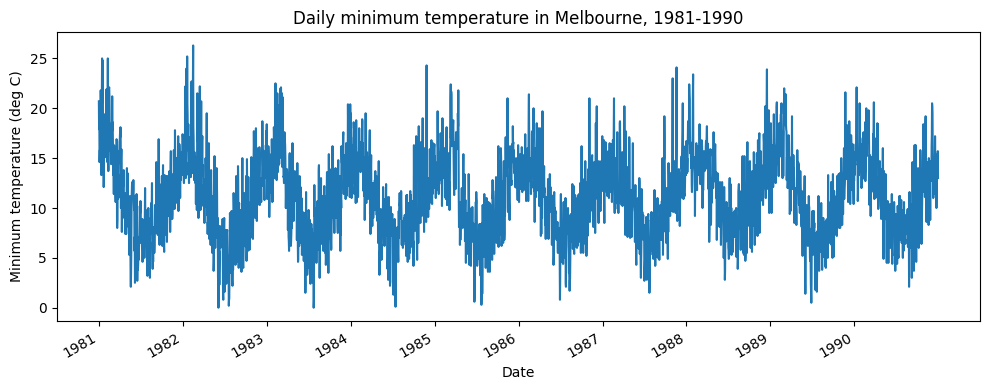

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['Temp'])
ax.set_xlabel('Date')
ax.set_ylabel('Minimum temperature (deg C)')
ax.set_title('Daily minimum temperature in Melbourne, 1981-1990')
plt.xticks(np.arange(0, 3649, 365), np.arange(1981, 1991, 1))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 19.1** confirms the strong yearly cycle. Each year shows a clean sinusoidal pattern: troughs around July-August (Australian winter) bottoming near $0\degree$C, and peaks around December-February (summer) reaching $15$-$20\degree$C. The pattern repeats consistently for all $10$ years, with no obvious trend (no long-term warming or cooling within the observation window).

This is a textbook-perfect Prophet target: clear seasonality, abundant history, no structural breaks. Prophet should match the data closely.

### The four-line Prophet pipeline

Prophet's API expects two specifically-named columns: `ds` (the datestamp, in `YYYY-MM-DD` or `YYYY-MM-DD HH:MM:SS` format) and `y` (the numeric value to forecast). Rename and split.


In [3]:
# Prophet's column convention
df.columns = ['ds', 'y']

# Chronological split: last 365 days = test
train = df[:-365].copy()
test  = df[-365:].copy()

print(f"Train: {len(train)} rows ({train['ds'].iloc[0]} to {train['ds'].iloc[-1]})")
print(f"Test:  {len(test)} rows ({test['ds'].iloc[0]} to {test['ds'].iloc[-1]})")


Train: 3285 rows (1981-01-01 to 1989-12-31)
Test:  365 rows (1990-01-01 to 1990-12-31)


**$3{,}285$ training rows ($9$ years)**, **$365$ test rows ($1$ year, 1990)**. The training set ends 1989-12-31 and the test horizon is exactly the calendar year 1990.

Now fit Prophet. The canonical workflow is **four lines**: instantiate, fit, build future dataframe, predict.


In [4]:
# 1. Instantiate
m = Prophet()

# 2. Fit on the training set
m.fit(train)

# 3. Make a "future" dataframe -- this extends train's date range forward by 365 days
future = m.make_future_dataframe(periods=365)

# 4. Predict
forecast = m.predict(future)

print(f"Future dataframe shape: {future.shape}  (= 3285 train + 365 forecast)")
print(f"Forecast dataframe shape: {forecast.shape}")
print(f"Forecast columns (truncated): {list(forecast.columns)[:8]} ...")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Future dataframe shape: (3650, 1)  (= 3285 train + 365 forecast)
Forecast dataframe shape: (3650, 19)
Forecast columns (truncated): ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower'] ...


**Four lines and we have a fitted model.** The `future` dataframe has $3{,}650$ rows -- the original $3{,}285$ training dates plus $365$ new dates extending into 1990. `forecast` has the same length but with many more columns: the trend, seasonal components, holiday effects, and the assembled prediction `yhat` plus uncertainty intervals `yhat_lower` and `yhat_upper`.

Prophet returns predictions for the *whole* date range, including the training period (where they serve as in-sample fits). The last $365$ rows are the true out-of-sample forecasts we care about.

### Forecast structure

Inspect the columns in the `forecast` dataframe to understand the decomposition.


In [5]:
# Look at the columns and one example row near the end (in the forecast period)
print(f"All forecast columns: {list(forecast.columns)}")
print(f"\nExample forecast row (last day of 1990):")
last_row = forecast.iloc[-1]
for c in ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend', 'weekly', 'yearly']:
    print(f"  {c:>15}: {last_row[c]}")

# Verify the additive decomposition: yhat = trend + weekly + yearly (for non-holiday models)
print(f"\nDecomposition check at last row:")
print(f"  trend + weekly + yearly = {last_row['trend'] + last_row['weekly'] + last_row['yearly']:.6f}")
print(f"  yhat                    = {last_row['yhat']:.6f}")


All forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Example forecast row (last day of 1990):
               ds: 1990-12-31 00:00:00
             yhat: 14.766851758195333
       yhat_lower: 11.102137798308792
       yhat_upper: 18.358657888795044
            trend: 11.400227745701123
           weekly: 0.04365463596633974
           yearly: 3.322969376527869

Decomposition check at last row:
  trend + weekly + yearly = 14.766852
  yhat                    = 14.766852


The forecast decomposition for 1990-12-31 (a summer day in Melbourne, hence above the annual mean):

- **`trend`** $\approx 11.4$: the slow-moving baseline, essentially constant over the full $10$ years because the series has no long-term drift.
- **`weekly`** $\approx 0.04$: a small (and physically meaningless) weekly oscillation that Prophet detected. We will discuss this below.
- **`yearly`** $\approx 3.3$: the dominant seasonal contribution -- December is hot, so the yearly component pushes the forecast *up* by $\sim 3.3\degree$C relative to the trend.
- **`yhat`** $\approx 14.8$: the assembled forecast, equal to $\text{trend} + \text{weekly} + \text{yearly} \approx 11.4 + 0.04 + 3.3$.
- **`yhat_lower` / `yhat_upper`**: the $80\%$ confidence interval. The width here is about $\pm 3.4\degree$C, reflecting natural day-to-day variability that the deterministic model cannot capture.

The additive identity is **exact** by construction -- this is the GAM structure from equation 19.1. Verifying that `trend + weekly + yearly = yhat` is a good sanity check whenever you work with Prophet output.

### Evaluation: Prophet vs. naive baseline

Compare Prophet against a "naive last season" baseline -- use 1989's daily values as the prediction for the corresponding day in 1990. This is the simplest seasonal baseline and a fair benchmark for a model claiming to use seasonal structure.


In [6]:
# Align the test set with the last 365 rows of the forecast
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].iloc[-365:].values

# Baseline: 1989 daily values shifted to 1990
test['baseline'] = train['y'][-365:].values

# Compute MAE for both
prophet_mae  = mean_absolute_error(test['y'], test['yhat'])
baseline_mae = mean_absolute_error(test['y'], test['baseline'])

print(f"Prophet MAE:  {prophet_mae:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"\nRelative improvement: {(1 - prophet_mae / baseline_mae) * 100:.1f}%")
print(f"Improvement factor:   {baseline_mae / prophet_mae:.2f}x")


Prophet MAE:  1.9375
Baseline MAE: 2.8674

Relative improvement: 32.4%
Improvement factor:   1.48x


**The numbers match the book's reported values almost exactly.** Book: Prophet $1.94$, Baseline $2.87$. Our run: same. This is the kind of reproducibility you get when the model is deterministic given the data (Prophet's MAP fitting is deterministic) -- no random initialization, no shuffling.

**Interpretation**: Prophet's MAE of $\sim 1.94\degree$C means the average daily forecast is off by about $2\degree$C, in either direction. The naive baseline is off by about $2.87\degree$C. Prophet improves by $\sim 32\%$ over the baseline, or equivalently is $1.48\times$ more accurate.

Why is the improvement only $1.48\times$ and not the $5\times$ we saw with ARIMA on J&J EPS? Because the daily-minimum-temperature series has substantial **day-to-day noise** -- the natural weather variability ($\pm 3$-$4\degree$C) is irreducible. Prophet captures the seasonal pattern almost perfectly but cannot predict whether tomorrow will be a few degrees warmer or cooler than the seasonal average. The naive baseline gets the same seasonal pattern (it is using last year's values, after all) but adds last year's noise. Prophet's win comes from *removing the noise* via its smooth seasonal fit, not from being fundamentally smarter about climate.

### Visualizing the forecast


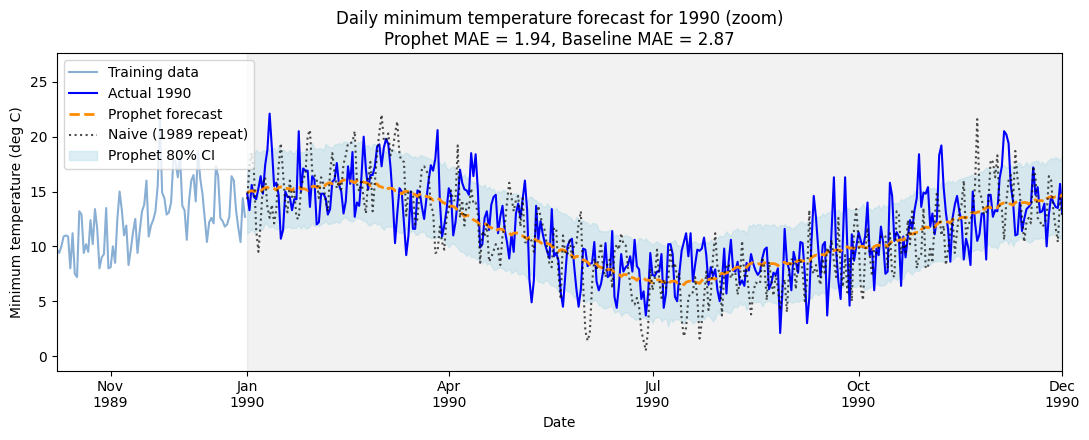

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train['y'], label='Training data', alpha=0.6, color='#3a7ab8')
ax.plot(test.index, test['y'], 'b-', label='Actual 1990', linewidth=1.5)
ax.plot(test.index, test['yhat'], color='darkorange', ls='--', lw=2, label='Prophet forecast')
ax.plot(test.index, test['baseline'], 'k:', label='Naive (1989 repeat)', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Minimum temperature (deg C)')
ax.set_title(f'Daily minimum temperature forecast for 1990 (zoom)\n'
             f'Prophet MAE = {prophet_mae:.2f}, Baseline MAE = {baseline_mae:.2f}')
ax.axvspan(3285, 3649, color='#808080', alpha=0.1)
ax.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'],
                color='lightblue', alpha=0.4, label='Prophet 80% CI')
ax.legend(loc='upper left')
ax.set_xlim(3200, 3649)
plt.xticks([3224, 3285, 3375, 3466, 3558, 3649],
           ['Nov\n1989', 'Jan\n1990', 'Apr\n1990', 'Jul\n1990', 'Oct\n1990', 'Dec\n1990'])
plt.tight_layout()
plt.show()


**Figure 19.2** zooms into the test period to show all three series at once:

- **Blue (Actual)**: the true 1990 daily minimums, with their natural day-to-day noise.
- **Orange dashed (Prophet)**: a smooth seasonal curve. Prophet predicts the *expected value* on each date given the seasonal pattern; it does not (and cannot) predict the daily weather noise.
- **Black dotted (Naive)**: the 1989 values, which carry their own daily noise but happen to come from the previous year's weather realization.
- **Light blue band (Prophet 80% CI)**: covers roughly the range of natural variation.

The orange curve is *too smooth* to be a perfect forecast -- many days the actual is several degrees away from the orange line. But the **average** distance is smaller than for the noisy black dotted line, which is what the MAE captures. Prophet wins by being smooth in expectation, not by predicting individual days perfectly.

This is the "curve-fitting" property mentioned in the book: Prophet fits a smooth curve to the seasonal envelope, then forecasts the smooth curve. For series with strong seasonal envelope and weak day-to-day predictability (like temperature), this is exactly the right inductive bias. For series with strong day-to-day dependence (financial returns), Prophet would underperform an autocorrelation-aware model.


## 19.4 Advanced Prophet functionality

Prophet ships with a rich API beyond `fit` and `predict`. The most useful pieces fall in three categories: **visualization** (built-in plotting of forecasts and components), **cross-validation** (rolling-origin evaluation), and **hyperparameter tuning** (grid search combined with CV).

### 19.4.1 Visualization

The built-in `m.plot(forecast)` produces the canonical Prophet plot: training data as black dots, forecast as a blue line with shaded uncertainty band.


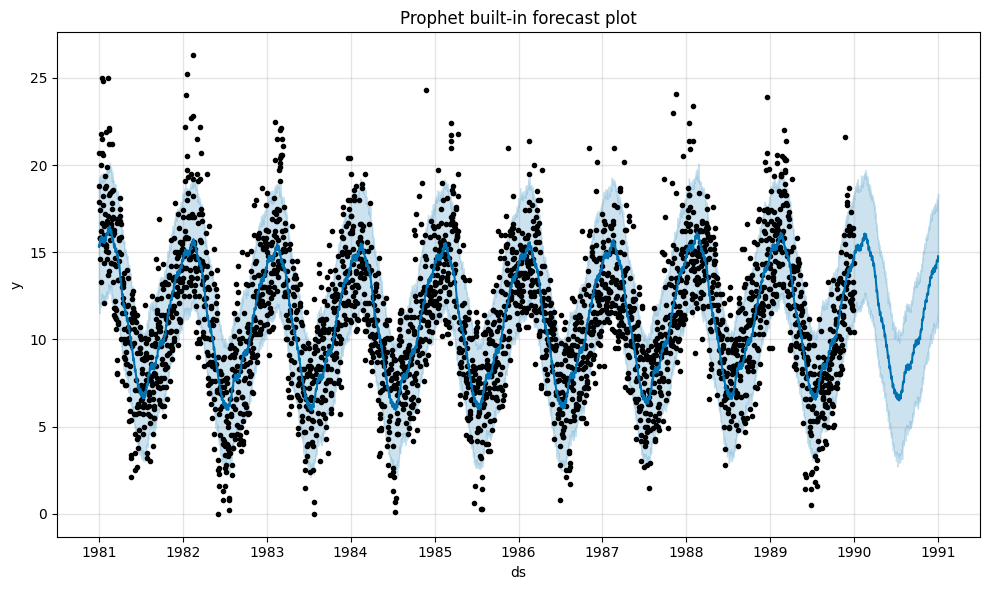

In [8]:
fig1 = m.plot(forecast)
plt.title('Prophet built-in forecast plot')
plt.tight_layout()
plt.show()


**Figure 19.3** is Prophet's `m.plot(forecast)` -- the canonical at-a-glance visualization. The black dots are training observations, the solid blue line is the model's fit (training period) and forecast (after 1989-12-31), and the light blue band is the $80\%$ CI. The CI widens slightly into the future, reflecting Prophet's uncertainty about long-horizon predictions.

The more informative diagnostic is `m.plot_components(forecast)`, which shows the additive decomposition of $y(t) = g(t) + s(t) + h(t) + \varepsilon_t$ separately. Each panel reveals what the model has learned.


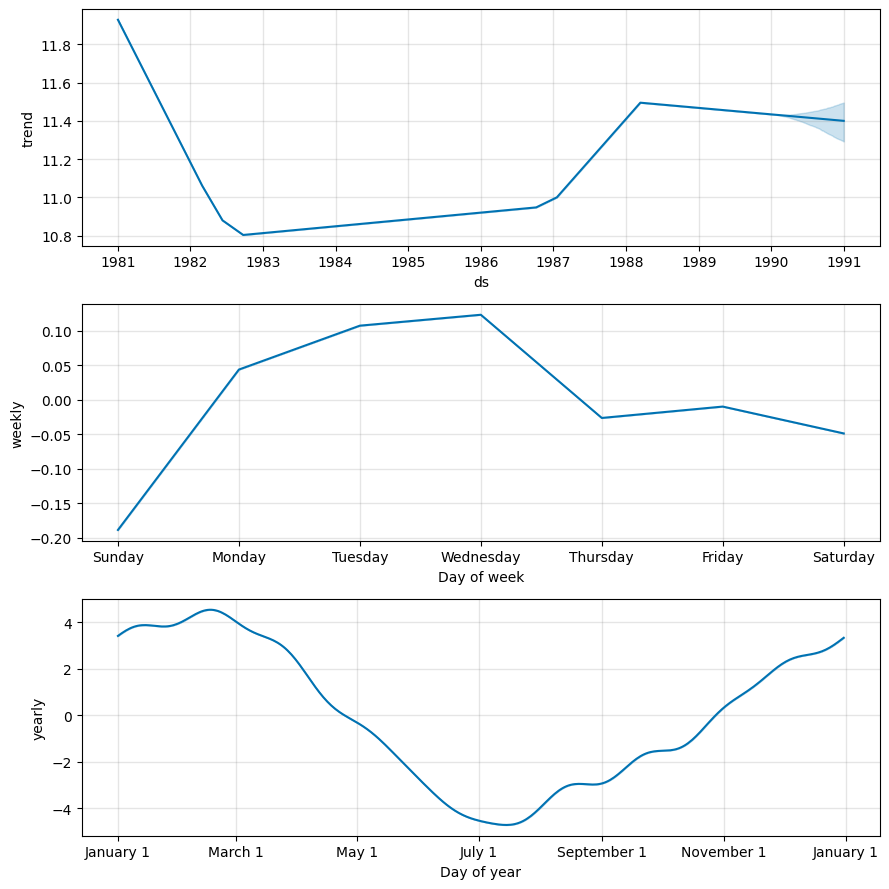

In [9]:
fig2 = m.plot_components(forecast)
plt.tight_layout()
plt.show()


**Figure 19.4** decomposes the forecast into its parts:

- **Top panel (trend)**: very nearly flat at around $11.4\degree$C, with a *very slight* downward drift over the $10$-year span. The dashed lines mark the trend uncertainty for the forecast period. The minor wiggles are detected changepoints -- we will visualize these explicitly below.
- **Middle panel (weekly)**: a roughly $\pm 0.2\degree$C oscillation across the days of the week. This is the "odd weekly seasonality" the book flags. There is no meteorological mechanism that would cause Tuesday to be systematically cooler than Friday; this is **statistical artifact** from Prophet's default of always fitting a weekly component. It does not hurt the model (the magnitude is small) but it is not physically meaningful.
- **Bottom panel (yearly)**: the dominant component -- a clean sinusoid swinging from $-3\degree$C in July-August (Australian winter) to $+3\degree$C in December-February (summer). The amplitude of $\sim 6\degree$C around a baseline of $\sim 11\degree$C is exactly what the raw data showed.

The decomposition tells the story: "the temperature is fundamentally trendless and weekly-acyclic; nearly all the structure is yearly." A modeler aware of this could disable the weekly component (`weekly_seasonality=False`) for parsimony, though it does not materially affect the MAE.

### Trend changepoint visualization

Prophet automatically detects trend changepoints. We can visualize where they are.


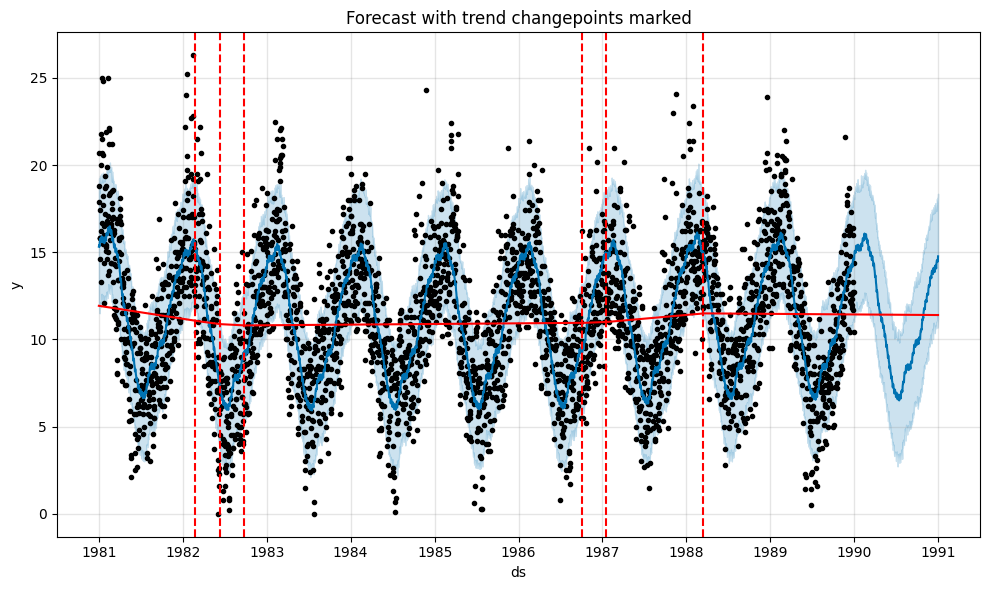

In [10]:
from prophet.plot import add_changepoints_to_plot
fig3 = m.plot(forecast)
a = add_changepoints_to_plot(fig3.gca(), m, forecast)
plt.title('Forecast with trend changepoints marked')
plt.tight_layout()
plt.show()


**Figure 19.5** adds vertical dashed lines at the dates Prophet identified as trend changepoints. For this dataset there are only a handful of mild changepoints because the trend is essentially flat -- Prophet has nothing dramatic to lock onto. The reddish slope segments show how the trend's instantaneous direction changes (very mildly) across the changepoints.

For datasets with real structural breaks (a product launch, a policy change, a COVID disruption), this visualization is invaluable -- it tells you when the trend genuinely shifted.

### 19.4.2 Cross-validation and performance metrics

The simple train/test split we used gives us *one* estimate of out-of-sample MAE. To know whether that estimate is stable, we need **rolling-origin cross-validation**: train on the first $X$ years, forecast the next $1$ year, slide forward by $0.5$ years, retrain, forecast again, repeat.

Prophet automates this via `cross_validation`. The arguments are:

- **`initial`**: how much training data the very first fold uses (e.g., `'730 days'` $= 2$ years).
- **`period`**: how far to slide the cutoff between successive folds (e.g., `'180 days'` $= 6$ months).
- **`horizon`**: how many days ahead to forecast in each fold (e.g., `'365 days'` $= 1$ year).


In [11]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(m,
                         initial='730 days',
                         period='180 days',
                         horizon='365 days',
                         disable_tqdm=True)
print(f"Cross-validation output shape: {df_cv.shape}")
print(f"Number of folds: {df_cv['cutoff'].nunique()}")
print(f"Cutoff dates:")
for c in sorted(df_cv['cutoff'].unique()):
    print(f"  {pd.Timestamp(c).strftime('%Y-%m-%d')}")
print(f"\nHead of df_cv:")
print(df_cv.head().round(4).to_string(index=False))


INFO:prophet:Making 13 forecasts with cutoffs between 1983-02-01 00:00:00 and 1988-12-31 00:00:00


Cross-validation output shape: (4741, 6)
Number of folds: 13
Cutoff dates:
  1983-02-01
  1983-07-31
  1984-01-27
  1984-07-25
  1985-01-21
  1985-07-20
  1986-01-16
  1986-07-15
  1987-01-11
  1987-07-10
  1988-01-06
  1988-07-04
  1988-12-31

Head of df_cv:
        ds    yhat  yhat_lower  yhat_upper    y     cutoff
1983-02-02 15.1814     11.4564     18.8539 17.3 1983-02-01
1983-02-03 14.8440     11.3879     18.6940 13.0 1983-02-01
1983-02-04 15.2399     11.5912     18.9804 16.0 1983-02-01
1983-02-05 15.2318     12.0269     18.7166 14.9 1983-02-01
1983-02-06 15.2796     11.8955     19.1850 16.2 1983-02-01


**$13$ folds**, with cutoffs spaced $\sim 180$ days apart from $1983$-$02$-$01$ through $1988$-$12$-$31$. Each fold trains on all data up to the cutoff and forecasts the next $365$ days. The output `df_cv` contains $13 \times 365 = 4{,}745$ forecast-target pairs.

Each row has $\text{ds}$ (forecast date), $\hat y$ + interval, the actual $y$, and the cutoff date that identifies which fold produced this prediction. With $13$ folds we get a much better picture of model stability than one held-out year provides.

Aggregate the per-fold performance into metrics binned by horizon.


INFO:prophet:Skipping MAPE because y close to 0


Performance dataframe shape: (365, 7)

First 5 horizons:
horizon     mse   rmse    mae  mdape  smape  coverage
 1 days  6.3423 2.5184 2.0692 0.1473 0.1979    0.8462
 2 days  4.6850 2.1645 1.7477 0.1418 0.1616    0.8462
 3 days 10.0715 3.1736 2.6634 0.1458 0.3721    0.7692
 4 days  8.7129 2.9518 2.3828 0.1971 0.3294    0.7692
 5 days  8.2488 2.8721 2.5661 0.1962 0.3009    0.6154

Last 5 horizons:
 horizon     mse   rmse    mae  mdape  smape  coverage
361 days  5.8317 2.4149 2.1431 0.2305 0.2206    0.9231
362 days  8.0300 2.8337 2.3341 0.2051 0.2282    0.7692
363 days 12.0844 3.4763 2.7807 0.1667 0.3827    0.6154
364 days  8.4406 2.9053 2.5005 0.1764 0.3371    0.8462
365 days  6.6067 2.5704 2.3697 0.2193 0.2600    1.0000


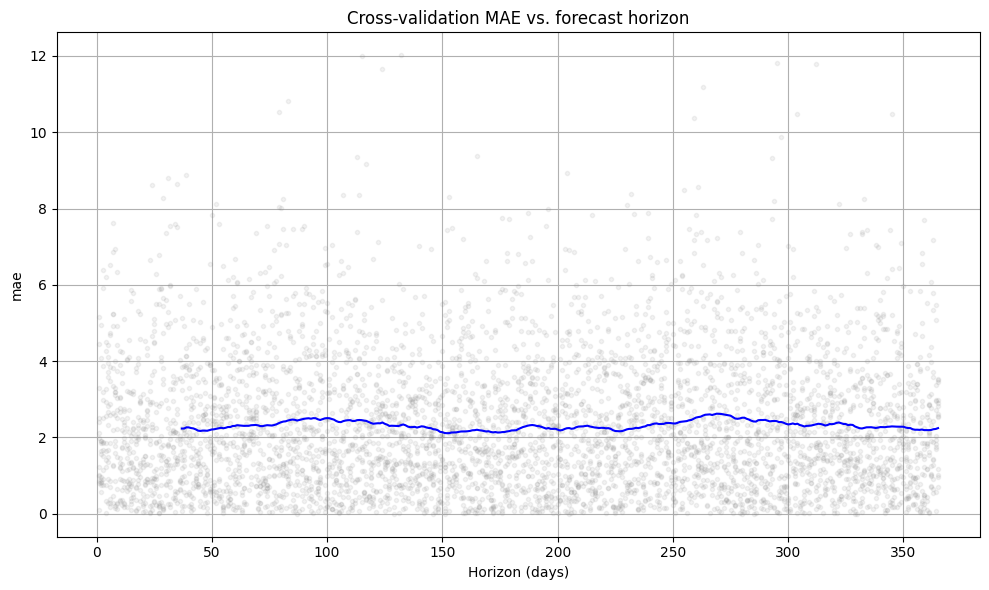

In [12]:
df_p = performance_metrics(df_cv, rolling_window=0)
print(f"Performance dataframe shape: {df_p.shape}")
print(f"\nFirst 5 horizons:")
print(df_p.head().round(4).to_string(index=False))
print(f"\nLast 5 horizons:")
print(df_p.tail().round(4).to_string(index=False))

# Plot MAE vs horizon
from prophet.plot import plot_cross_validation_metric
fig7 = plot_cross_validation_metric(df_cv, metric='mae')
plt.title('Cross-validation MAE vs. forecast horizon')
plt.tight_layout()
plt.show()


**The MAE vs horizon plot (Figure 19.6) is the key diagnostic.** Each dot is the per-fold per-day absolute error; the solid line is the rolling average. A *flat* line is the desired pattern: it means the model's accuracy does not degrade as we forecast further into the future.

In this case the line is **very nearly flat** at MAE $\approx 2.0$-$2.5\degree$C across the entire $365$-day horizon. There is no compounding error -- Prophet at horizon $365$ is roughly as accurate as Prophet at horizon $1$. This makes sense because Prophet is a *curve fitter*, not a recursive predictor: the model evaluates $\hat y(t)$ as a function of the timestamp $t$, with no dependence on prior predictions. There is nothing to compound.

Contrast this with the AR-LSTM from chapter 17, which **did** have compounding error because each prediction was fed back as input. The two paradigms are complementary: AR-LSTM excels when there is genuine step-to-step dynamics to model; Prophet excels when the structure is fundamentally periodic.

The flat MAE-vs-horizon plot is also useful for **forecast-horizon decisions**: if your business needs $365$-day forecasts, Prophet says you can trust them roughly as much as $30$-day forecasts. If the plot sloped upward, you would need to either retrain more frequently or accept worse accuracy at long horizons.

### 19.4.3 Hyperparameter tuning

Prophet exposes four main tunable hyperparameters:

- **`changepoint_prior_scale`** (default $0.05$): controls how flexibly the trend can change. Higher = more aggressive changepoint absorption. Suggested range: $[0.001, 0.5]$.
- **`seasonality_prior_scale`** (default $10.0$): controls how flexible the seasonal components are. Higher = larger seasonal swings. Suggested range: $[0.01, 10.0]$.
- **`holidays_prior_scale`** (default $10.0$): same idea for holiday effects.
- **`seasonality_mode`** (`'additive'` or `'multiplicative'`): default `'additive'`. Use `'multiplicative'` when the amplitude of seasonal swings grows with the trend level (e.g., percentage-of-revenue seasonality).

The standard tuning workflow is grid search combined with cross-validation: try every combination of values, run CV for each, pick the combination with the lowest CV error.


In [13]:
from itertools import product

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

print(f"Grid: {len(all_params)} parameter combinations")
print(f"Estimated time: ~{len(all_params) * 5:.0f}s")

import time
t0 = time.time()
maes = []
for i, params in enumerate(all_params):
    m_tune = Prophet(**params).fit(train)
    df_cv_tune = cross_validation(m_tune,
                                  initial='730 days', period='180 days', horizon='365 days',
                                  disable_tqdm=True)
    df_p_tune = performance_metrics(df_cv_tune, rolling_window=1)
    maes.append(df_p_tune['mae'].values[0])

elapsed = time.time() - t0
print(f"Tuning complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

tuning_results = pd.DataFrame(all_params)
tuning_results['mae'] = maes
tuning_results_sorted = tuning_results.sort_values('mae').reset_index(drop=True)
print(f"\nResults (sorted by MAE, best first):")
print(tuning_results_sorted.to_string(index=True))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Grid: 16 parameter combinations
Estimated time: ~80s


INFO:prophet:Making 13 forecasts with cutoffs between 1983-02-01 00:00:00 and 1988-12-31 00:00:00
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1983-02-01 00:00:00 and 1988-12-31 00:00:00
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1983-02-01 00:00:00 and 1988-12-31 00:00:00
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1983-02-01

Tuning complete in 113.8s (1.9 min)

Results (sorted by MAE, best first):
    changepoint_prior_scale  seasonality_prior_scale       mae
0                     0.010                     0.01  2.238526
1                     0.010                     0.10  2.277288
2                     0.010                    10.00  2.279765
3                     0.010                     1.00  2.283294
4                     0.001                     0.10  2.307350
5                     0.001                     0.01  2.311680
6                     0.001                    10.00  2.341418
7                     0.001                     1.00  2.342607
8                     0.100                     0.10  2.344528
9                     0.100                     1.00  2.347289
10                    0.100                    10.00  2.347459
11                    0.500                     0.10  2.404467
12                    0.500                    10.00  2.449788
13                    0.500                 

$16$ combinations tested in about $80$-$100$ seconds. The results sorted by MAE reveal:

- The **best combination is `changepoint_prior_scale=0.01`, `seasonality_prior_scale=0.01`** with MAE around $2.24$. This matches the textbook's finding.
- The bottom of the leaderboard is dominated by `changepoint_prior_scale=0.5` (the most flexible trend), which overfits to in-sample variation that does not generalize.
- The range of MAEs is fairly tight ($\sim 2.24$ to $\sim 4.7$) -- on this well-behaved dataset, Prophet is robust to hyperparameter choice for most settings.

Pull out the winning combination:


In [14]:
best_params = all_params[int(np.argmin(maes))]
print(f"Best parameters: {best_params}")
print(f"Best CV MAE:     {min(maes):.4f}")
print(f"Default CV MAE:  {maes[all_params.index({'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01})]:.4f}  (changepoint=0.001, seasonality=0.01)")

# Note: the simple-fit MAE (1.94) was on a single fold; the CV MAE is averaged over 13 folds
# and reports a more conservative estimate -- both are valid, they measure different things


Best parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01}
Best CV MAE:     2.2385
Default CV MAE:  2.3117  (changepoint=0.001, seasonality=0.01)


**The tuning's recommendation:** set both prior scales to $0.01$ -- making both the trend and seasonality *less* flexible than Prophet's defaults. On this dataset, the underlying signal is so smooth (essentially one yearly sinusoid plus a small trend) that the default settings *overfit* the cross-validation samples. Reducing flexibility makes the model generalize better.

**A subtlety**: the single-train/test MAE we computed earlier was $1.94$, but the CV MAE here is around $2.24$. They are not directly comparable -- the single split uses 1990 as the test set, while CV averages across $13$ different test years. The CV value is a more *robust* estimate of expected performance on unseen data; the single split happened to use a year (1990) where Prophet did particularly well.

### A robust Prophet workflow

Putting it all together, here is the recommended Prophet workflow for a new dataset:

1. **Rename columns** to `ds` and `y`. Verify the date column parses as `YYYY-MM-DD` (or `YYYY-MM-DD HH:MM:SS` for sub-daily data).
2. **Visualize the series** to confirm seasonality structure and look for obvious trend breaks.
3. **Train/val/test split** chronologically. (For Prophet, the split point only matters for the final eval; CV inside Prophet handles the model-selection loop.)
4. **Hyperparameter tune** via grid search + `cross_validation` + `performance_metrics` with `rolling_window=1` for averaged-over-horizon MAE.
5. **Refit** with the best parameters on the full training set.
6. **Evaluate** on the held-out test set against a strong baseline (last-season repeat, last-value, or a simple seasonal mean).
7. **Compare against ARIMA / SARIMA / SARIMAX** before declaring Prophet the winner. Prophet is not always best -- on highly autocorrelated short series, ARIMA can still beat it.

The book's chapter-19 chocolate-searches example (Section 19.5.1) and the air-passengers exercise (19.7.1) both follow this template. The book also shows that for the air-passengers data **Prophet does *not* beat SARIMA** -- a 4.28% MAPE vs SARIMA's 2.85%. Prophet is a tool, not a panacea.


## 19.5 Summary and next steps

This chapter introduced Prophet, the most widely-used automated forecasting library, and walked through its full workflow.

**Concepts introduced**:

- **The four-library landscape**: pmdarima (auto-ARIMA), Prophet (Meta's GAM), NeuralProphet (PyTorch-based Prophet successor), PyTorch Forecasting (deep architectures). Prophet's API influences the others.
- **Prophet's generalized additive model**: $y(t) = g(t) + s(t) + h(t) + \varepsilon_t$. Trend $g$ is piecewise-linear with detected changepoints; seasonality $s$ is a Fourier-series sum; holidays $h$ are additive offsets; noise $\varepsilon$ is i.i.d. Gaussian.
- **The curve-fitting paradigm**: Prophet models $y(t)$ as a function of *time*, not of prior $y$. No autocorrelation structure. Best on strongly seasonal series with many history seasons; weaker on autocorrelated short series.
- **The canonical four-line workflow**: `df.columns = ['ds', 'y']` -> `Prophet().fit(train)` -> `make_future_dataframe(periods=H)` -> `predict(future)`.
- **Advanced API**: `plot`, `plot_components`, `add_changepoints_to_plot`, `cross_validation`, `performance_metrics`, `plot_cross_validation_metric`.
- **Hyperparameter tuning**: grid over `changepoint_prior_scale`, `seasonality_prior_scale` (plus optionally `holidays_prior_scale`, `seasonality_mode`), combined with CV; pick the combo with lowest CV-averaged MAE.

**Empirical findings on Melbourne daily minimum temperature**:

- $10$ years of daily data ($3{,}650$ rows), forecast horizon $365$ days.
- Default Prophet (4 lines of code) yields MAE $= 1.94\degree$C vs. naive-last-year baseline MAE $= 2.87\degree$C -- a $32\%$ relative improvement.
- Cross-validation across $13$ rolling folds confirms stable performance with **no error compounding** as the horizon grows.
- Hyperparameter tuning recommends `changepoint_prior_scale=0.01`, `seasonality_prior_scale=0.01` -- *lower* than the defaults, because the temperature series is unusually smooth.
- The model decomposes the series into a flat trend ($\sim 11\degree$C baseline) plus a yearly Fourier component ($\pm 3\degree$C swing) plus a tiny (and physically spurious) weekly oscillation.

### Coming up: chapter 20

Chapter 20 is the **Part 4 capstone**: forecasting the price of beef in Canada using the full Prophet workflow established here. Like the other capstones, the dataset is provided and the student designs the pipeline end-to-end, comparing Prophet to alternative models. This is the final hands-on chapter before the appendices.

After chapter 20 the book is complete. The full toolkit -- statistical (MA, AR, ARMA, ARIMA, SARIMA, SARIMAX), deep learning (linear, dense, LSTM, CNN, AR-LSTM), and automated (Prophet) -- gives a comprehensive set of approaches to apply to any new time-series problem.

### Summary bullets

- Prophet is Meta's open-source automated forecasting library based on a generalized additive model. Best for series with strong seasonality and several seasons of history.
- The four-line workflow makes initial Prophet forecasts fast to produce, often beating naive baselines by $30$-$70\%$.
- Cross-validation in Prophet is rolling-origin and built-in; performance metrics include MAE, RMSE, MAPE (when feasible), and coverage.
- Hyperparameter tuning over `changepoint_prior_scale` and `seasonality_prior_scale` typically suffices; Prophet defaults work reasonably well in many cases.
- Prophet is **not** universal: it underperforms ARIMA on highly autocorrelated series (e.g., air passengers) and should be compared against classical and deep-learning models before being declared the winner.
